32033
<generator object <genexpr> at 0x00000170B5CCB2E0>
torch.Size([182625, 8]) torch.Size([182625])
torch.Size([22655, 8]) torch.Size([22655])
torch.Size([22866, 8]) torch.Size([22866])
........ --> y
.......y --> u
......yu --> h
.....yuh --> e
....yuhe --> n
...yuhen --> g
..yuheng --> .
........ --> d
.......d --> i
......di --> o
.....dio --> n
....dion --> d
...diond --> r
..diondr --> e
.diondre --> .
........ --> x
.......x --> a
......xa --> v
.....xav --> i
....xavi --> e
22097
      0/ 200000: 3.2847
  10000/ 200000: 2.0647
  20000/ 200000: 1.9722
  30000/ 200000: 2.0948
  40000/ 200000: 1.9738
  50000/ 200000: 2.1287
  60000/ 200000: 2.3574
  70000/ 200000: 1.9131
  80000/ 200000: 2.0735
  90000/ 200000: 2.0968
 100000/ 200000: 1.4963
 110000/ 200000: 2.1294
 120000/ 200000: 2.2324
 130000/ 200000: 2.2071
 140000/ 200000: 2.2326
 150000/ 200000: 1.8908
 160000/ 200000: 1.6867
 170000/ 200000: 2.0968
 180000/ 200000: 1.7824
 190000/ 200000: 1.9151
train 1.9163438081741333
v

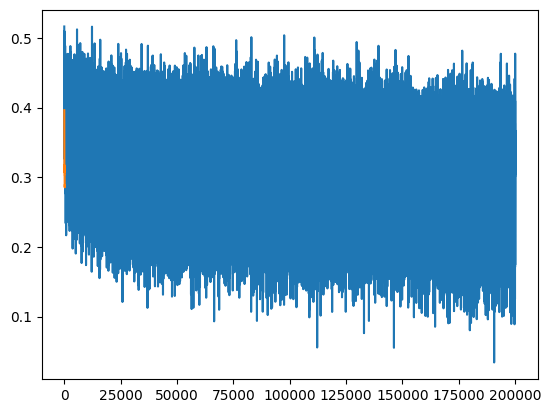

In [1]:
import torch 
import torch.nn.functional as F
import matplotlib.pyplot as plt
words = open("names.txt","r").read().splitlines()
print(len(words))
print(max(len(w)) for w in words)
chars = sorted(set(list("".join(words))))
stoi = {s : i+1 for i, s in enumerate(chars)}
stoi["."] = 0
itos = {i : s for s,i in stoi.items()}
vocab_size = len(stoi)
import random
random.seed(42)
random.shuffle(words)
block_size = 8

def build_dataset(words):

  X, Y = [],[]


  for w in words:

    context = [0] * block_size
    for ch in w + ".":
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix]


  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape,Y.shape)
  return X, Y

n1 = int(len(words) * 0.8)
n2 = int(len(words) * 0.9)
Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%
for x,y in zip(Xtr[:20],Ytr[:20]):
  print(''.join(itos[ix.item()] for ix in x), "-->", itos[y.item()])
  class Linear:

    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out)) / fan_in**0.5
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])


class BatchNorm1d:

    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True

        # Geri yayılımla öğrenilen parametreler
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)

        # Eğitim boyunca güncellenen istatistikler
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x):
        if self.training:
            xmean = x.mean(0, keepdim=True)
            xvar = x.var(0, keepdim=True)
        else:
            xmean = self.running_mean
            xvar = self.running_var

        xhat = (x - xmean) / torch.sqrt(xvar + self.eps)
        self.out = self.gamma * xhat + self.beta

        if self.training:
            with torch.no_grad():
                self.running_mean = (
                    (1 - self.momentum) * self.running_mean
                    + self.momentum * xmean
                )
                self.running_var = (
                    (1 - self.momentum) * self.running_var
                    + self.momentum * xvar
                )

        return self.out

    def parameters(self):
        return [self.gamma, self.beta]


class Tanh:

    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out

    def parameters(self):
        return []
    # ---------------------------------------------------------------------------
class Embedding:

    def __init__(self, num_embeddings, embedding_dim):
        self.weight = torch.randn((num_embeddings, embedding_dim))

    def __call__(self, IX):
        self.out = self.weight[IX]
        return self.out

    def parameters(self):
        return [self.weight]


# ---------------------------------------------------------------------------
class Flatten:

    def __call__(self, x):
        self.out = x.view(x.shape[0], -1)
        return self.out

    def parameters(self):
        return []
#Sequential.parameters() ise bütün katmanların parametrelerini dolaşıp tek bir listede topluyor. Böylece eğitim sırasında güncellenecek parametrelere model üzerinden erişiyorum.”
class Sequential: # model(Xb)

    def __init__(self, layers):
        self.layers = layers

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        self.out = x
        return self.out

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

torch.manual_seed(42)

n_embd = 10
n_hidden = 200

# C = torch.randn((vocab_size, n_embd))

model = Sequential([
    Embedding(vocab_size,n_embd), 
    Flatten(),   
    Linear(n_embd * block_size, n_hidden, bias=False),
    BatchNorm1d(n_hidden),
    Tanh(),
    Linear(n_hidden, vocab_size),
])
# Son katmanın ağırlıklarını 0.1 ile küçültüyorum; başlangıçta çok büyük logits ve aşırı emin tahminler oluşmasını azaltmak istiyorum
with torch.no_grad():
    model.layers[-1].weight *= 0.1

parameters =  model.parameters() # [C] + [p for layer in layers for p in layer.parameters()]

print(sum(p.nelement() for p in parameters))

for p in parameters:
    p.requires_grad = True
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    # Minibatch oluştur
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix], Ytr[ix]

    
    # Forward pass

    logits = model(Xb)
    loss = F.cross_entropy(logits, Yb)
    # emb = C[Xb]
    # x = emb.view(emb.shape[0], -1)
    x = Xb



    # Geri yayılım
    for p in parameters:
        p.grad = None

    loss.backward()

    # Parametre güncellemesi
    lr = 0.1 if i < 150000 else 0.01

    for p in parameters:
        p.data += -lr * p.grad

    # Kayıp değerini izle
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')

    lossi.append(loss.log10().item())
plt.plot(lossi) # karoathy bu grafikten kurtulmak istiyor
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))
for layer in model.layers:
    layer.training = False

@torch.no_grad()
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]

    logits = model(x)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')
split_loss('test')
for _ in range(20):
    
    out = []
    context = [0] * block_size 
    while True:
  
      logits = model(torch.tensor([context]))
      probs = F.softmax(logits, dim=1)

      ix = torch.multinomial(probs, num_samples=1).item()

      context = context[1:] + [ix]
      out.append(ix)

      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out)) 

In [2]:
dev_loss_3 = 2.106257200241089
dev_loss_8 = 2.034247875213623
print(f"Dev loss düşüşü: {dev_loss_3 - dev_loss_8:.4f}")

Dev loss düşüşü: 0.0720
